In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import random

# Exploratory Data Analysis

In [4]:
# import the sony stock csv file and parse the dates to datetime format compatible with pandas library
df = pd.read_csv('./sony_stock_data.csv', parse_dates=['Date'])
# set the Date column as the index (optional, but helpful)
df = df.set_index('Date')
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2014-01-02,3.203941,3.246884,3.189004,3.235681,13127000
2014-01-03,3.207675,3.222611,3.196472,3.213276,4642000
2014-01-06,3.230079,3.265554,3.224478,3.230079,11781500
2014-01-07,3.233814,3.245017,3.211409,3.241283,17191500
2014-01-08,3.407454,3.420523,3.222611,3.248750,42864500


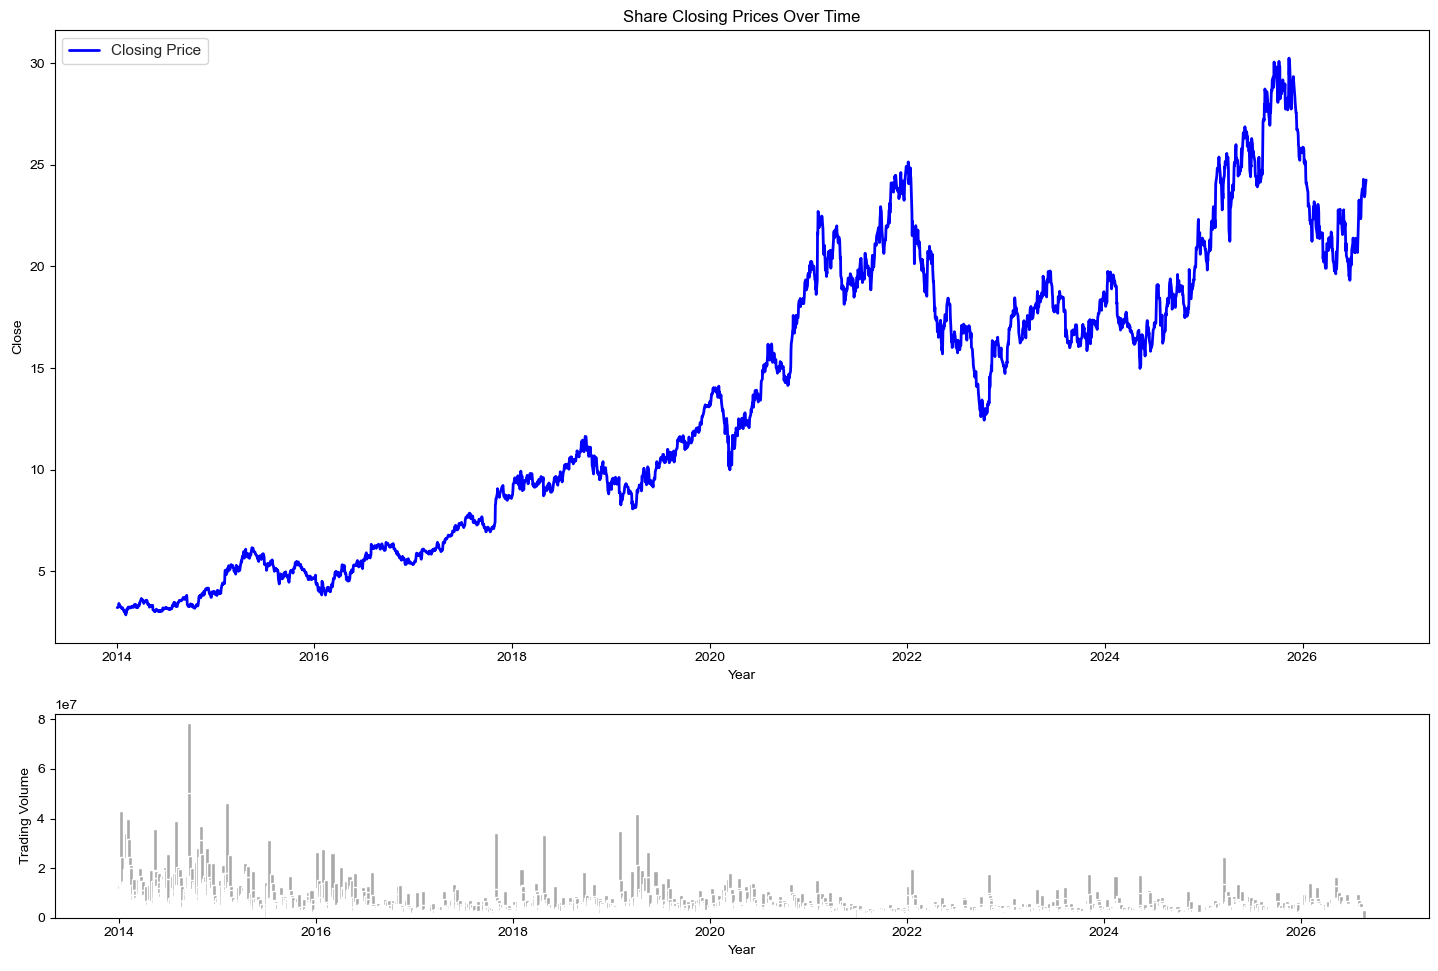

In [6]:
# plot the dates against the closing prices and volumes
plt.rc('figure', figsize=(15, 10))
fig, axes = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]})
fig.tight_layout(pad=3)
sns.set(style="whitegrid") 
sns.lineplot(x=df.index, y=df['Close'], label='Closing Price', color='blue', ax=axes[0], linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Close')
axes[1].bar(df.index, df['Volume'], color='darkgrey', width=15)
axes[0].set_title('Share Closing Prices Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Trading Volume')
plt.show()

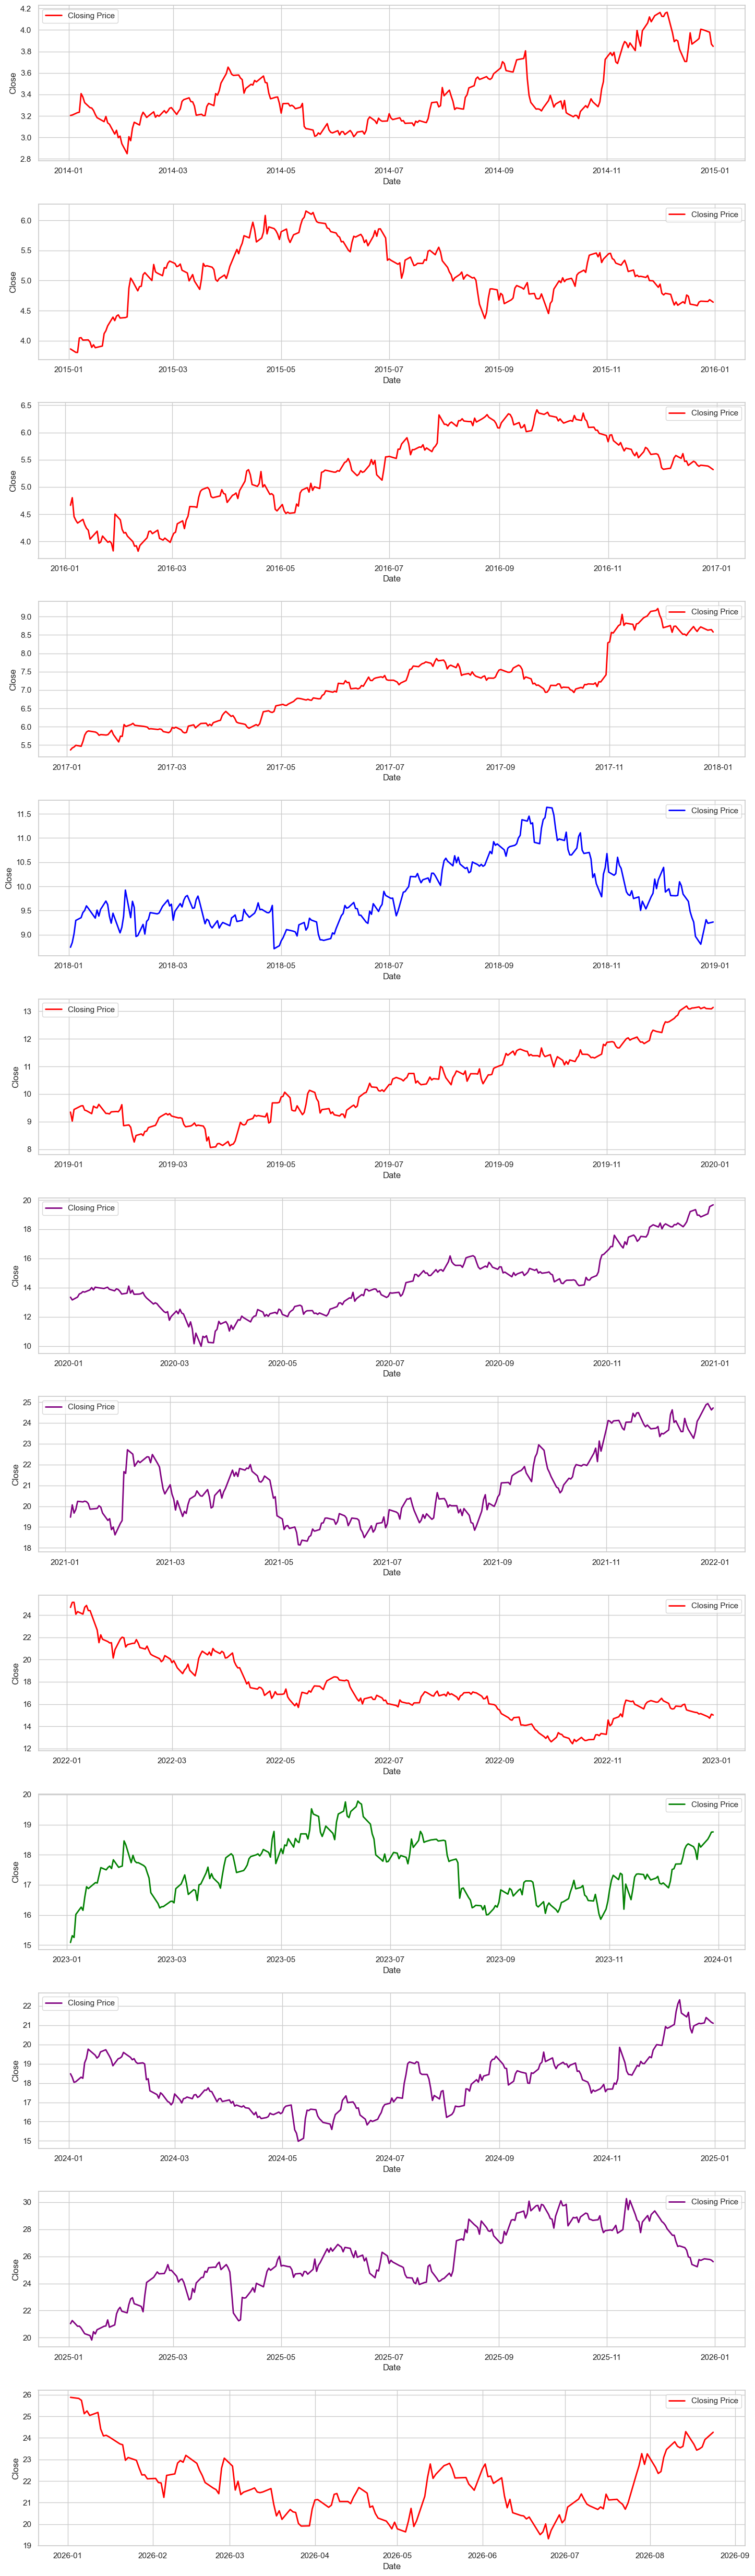

In [7]:
# plot times by months for each year
years = [i for i in df.index.year.unique()]
plt.rc('figure', figsize=(15, 50))
fig, axs = plt.subplots(13, 1)
fig.tight_layout(pad=3)
sns.set(style="whitegrid") 

count = 0
colors = ['blue', 'red', 'purple', 'green']

for i in range(years[0], years[-1]+1):
    sns.lineplot(x=df.loc[df.index.year == i].index, y=df.loc[df.index.year == i]['Close'], label='Closing Price', color=random.choice(colors), ax=axs[count], linewidth=2)
    count = count+1

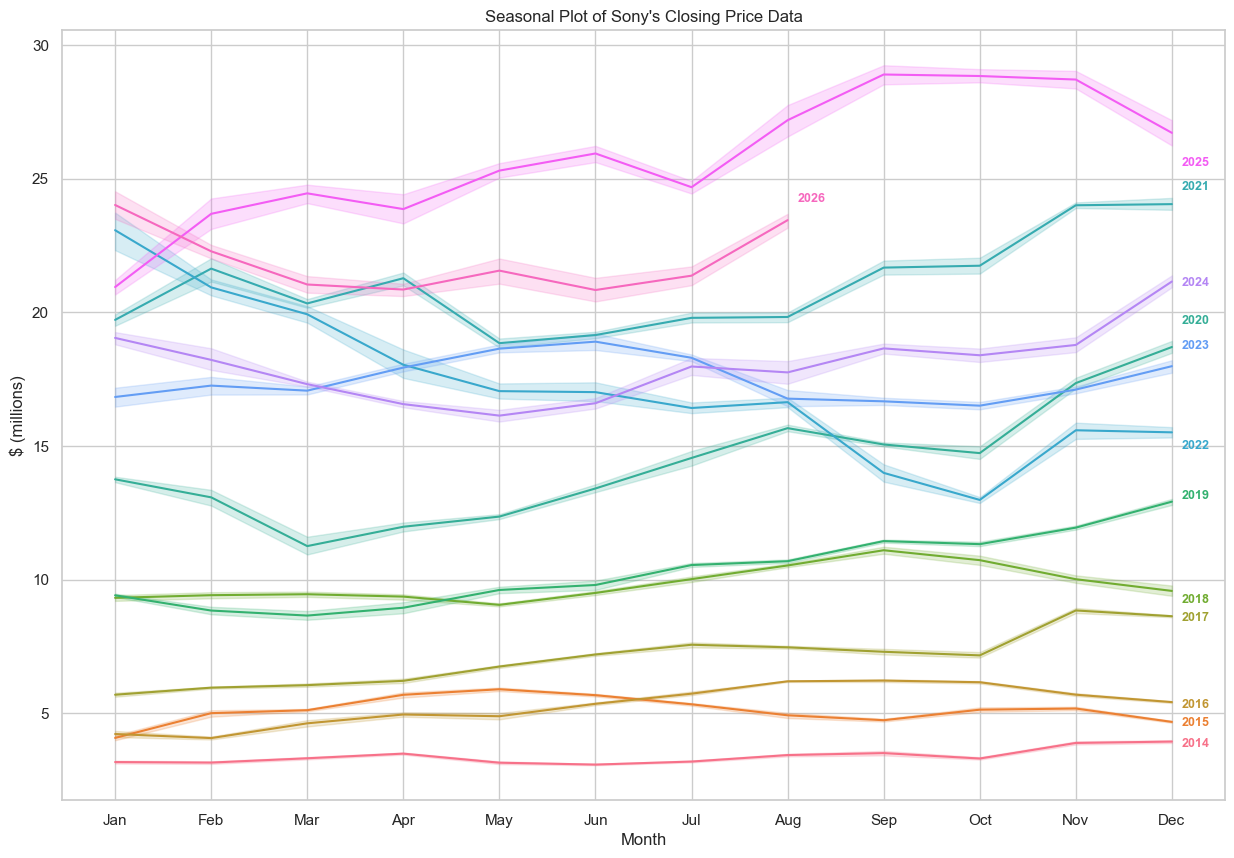

In [9]:
# seasonal subseries plot
df_copy = df.copy()

year_palette = sns.color_palette("husl", n_colors=len(years))
fig, ax = plt.subplots(figsize=(15, 10))

df_copy['Month_num'] = df.index.month
df_copy['Year'] = df.index.year

sns.lineplot(data=df_copy, x="Month_num", y="Close",
  hue="Year", palette=year_palette, legend=False, ax=ax)

ax.set(
    title="Seasonal Plot of Sony's Closing Price Data",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)

min_year = np.array(years).min()

for year, subset in df_copy.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Close"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="center", fontsize=9, weight="bold", color=color)

plt.savefig('seasonal_plot')
plt.show()

/var/folders/2j/1q6627rd63n0qq4cxzs4fn6r0000gn/T/ipykernel_18520/2001939016.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


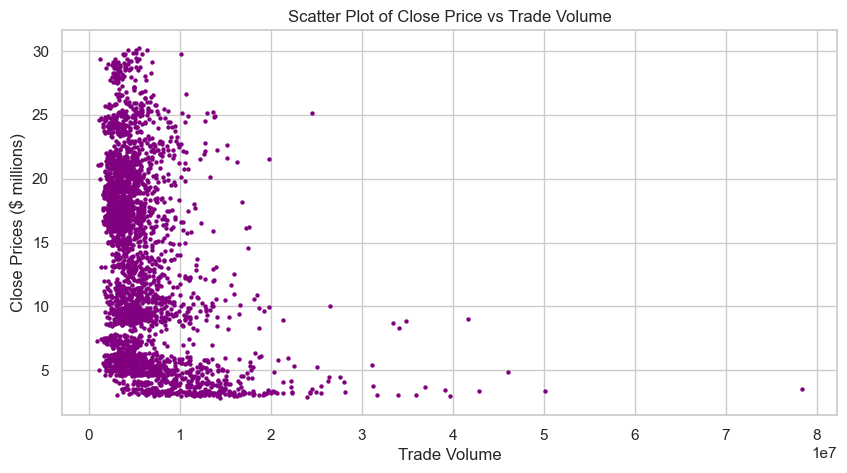

In [13]:
# relationship b/w close price and stock trade volumes
fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(data=df, x="Volume", y="Close",
    ax=ax, linewidth=0, s=10, legend=False, color='purple')
ax.set(
    title="Scatter Plot of Close Price vs Trade Volume",
    xlabel="Trade Volume",
    ylabel="Close Prices ($ millions)",
)
fig.show()


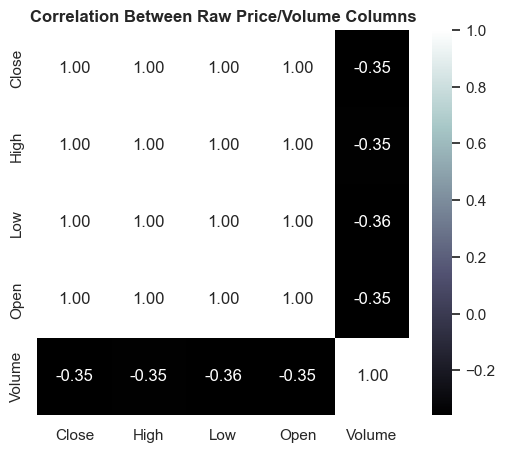

In [14]:
# plot the linearity measures of each feature

plt.figure(figsize=(6, 5))
sns.heatmap(df[["Close", "High", "Low", "Open", "Volume"]].corr(),
            annot=True, cmap="bone", fmt=".2f")
plt.title("Correlation Between Raw Price/Volume Columns", fontweight='bold')
plt.show()

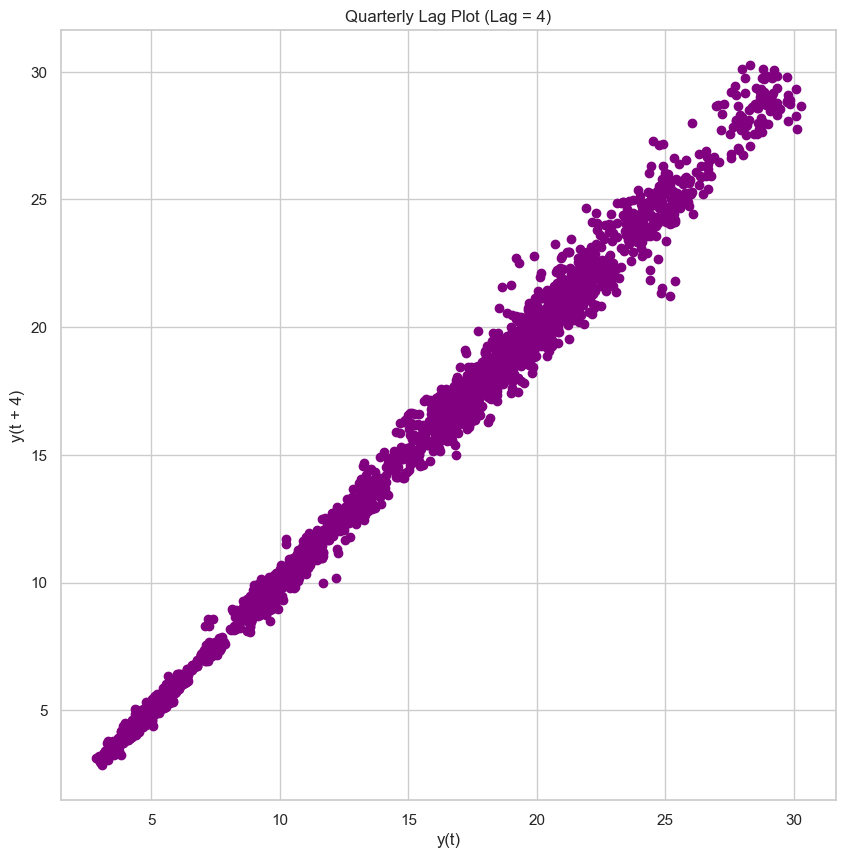

In [11]:
# lag plots by yearly quarter of closing prices and trade volumes
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('figure', figsize=(10, 10))
pd.plotting.lag_plot(df['Close'], lag=4, c='purple')
plt.title("Quarterly Lag Plot (Lag = 4)")
plt.savefig('quarterly_lag_plot.png')
plt.show()